### Install Required Python Packages

In [1]:
!pip install -q -r requirements.txt

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

%matplotlib inline
sns.set_theme(style="whitegrid")

### Load Dataset

In [3]:
csv_path = "Dataset/dataset_v1.csv"
df = pd.read_csv(csv_path)
if "task_id" in df.columns:
    df = df.drop(columns=["task_id"])
print(f"Initial Dataset shape: {df.shape}")

Initial Dataset shape: (1968, 8)


### Data Cleanup

In [4]:
print(df["predicted_bug_type"].value_counts())

predicted_bug_type
value misuse                                 493
operator misuse                              433
missing logic                                370
unknown                                      290
variable misuse                              186
excess logic                                 139
function misuse                               15
value misuse**                                 6
operator misuse**                              6
excess logic**                                 5
logic error                                    4
variable misuse**                              4
missing logic**                                4
logic misuse                                   2
** value misuse                                2
logic                                          1
variable and function misuse                   1
logical error                                  1
expected behavior                              1
excess logic </h1>                             1
v

In [5]:
df["predicted_bug_type_clean"] = df["predicted_bug_type"].str.strip().str.replace(r"^\*+|\*+$", "", regex=True)
canonical_map = {
    "value misuse": "value misuse",
    "operator misuse": "operator misuse",
    "missing logic": "missing logic",
    "excess logic": "excess logic",
    "variable misuse": "variable misuse",
    "function misuse": "function misuse",
    "value misuse, missing logic, excess logic": "unknown",
    "no bug": "unknown",
    "expected behavior": "unknown",
    "excess logic </h1>": "unknown",
    "variable and function misuse": "unknown",
    "logical error": "unknown",
    "logic error": "unknown",
    "syntax error": "unknown",
    "logic misuse": "unknown",
    "logic": "unknown",
    "operator misuse and variable misuse": "unknown",
}
def standardize(val):
    if not isinstance(val, str):
        return "unknown"
    norm = re.sub(r"[^\w]+", "", val.lower())
    for k, v in canonical_map.items():
        if re.sub(r"[^\w]+", "", k.lower()) == norm:
            return v
    return val
df["predicted_bug_type"] = df["predicted_bug_type_clean"].apply(standardize)
df.drop(columns=["predicted_bug_type_clean"], inplace=True)

for col in ["fix_success", "diagnosis_match"]:
    if col in df.columns:
        df[col] = df[col].astype(int)
print("\nMissing values:\n", df.isna().sum())


Missing values:
 language                0
model_name              0
true_bug_type           0
true_failure_symptom    0
predicted_bug_type      0
diagnosis_match         0
code_length             0
fix_success             0
dtype: int64


## EDA & Visualizations

In [6]:
for col in ['language', 'model_name', 'true_bug_type', 'predicted_bug_type']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


language value counts:
language
python    492
cpp       492
java      492
js        492
Name: count, dtype: int64

model_name value counts:
model_name
qwen2.5-coder:7b       656
deepseek-coder:6.7b    656
llama3.1:8b            656
Name: count, dtype: int64

true_bug_type value counts:
true_bug_type
value misuse       528
missing logic      396
excess logic       372
operator misuse    300
variable misuse    276
function misuse     96
Name: count, dtype: int64

predicted_bug_type value counts:
predicted_bug_type
value misuse       501
operator misuse    439
missing logic      374
unknown            305
variable misuse    190
excess logic       144
function misuse     15
Name: count, dtype: int64


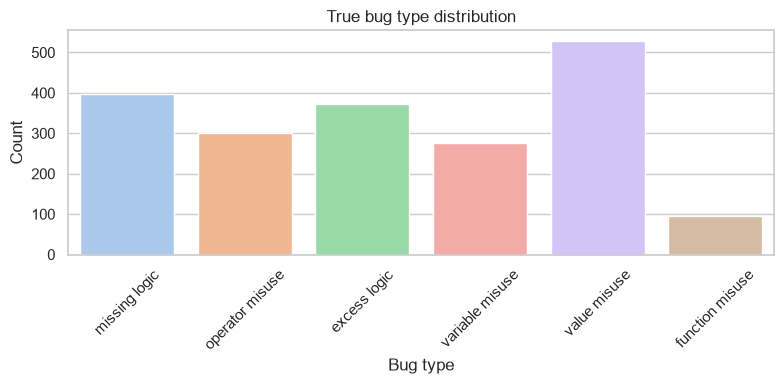

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="true_bug_type", palette="pastel", hue= "true_bug_type", legend=False)
plt.title("True bug type distribution")
plt.xlabel("Bug type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

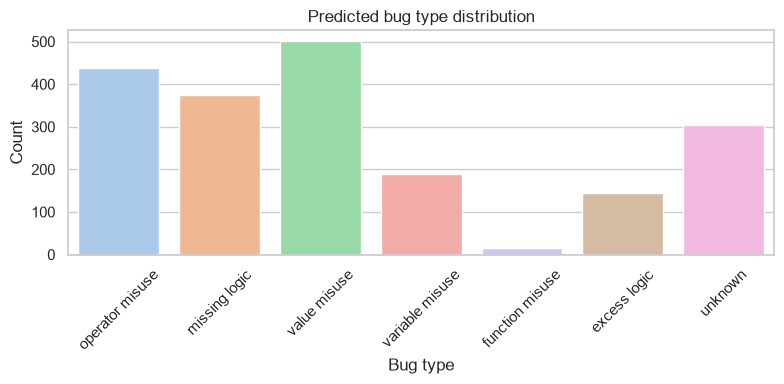

In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="predicted_bug_type", palette="pastel", hue= "predicted_bug_type", legend=False)
plt.title("Predicted bug type distribution")
plt.xlabel("Bug type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

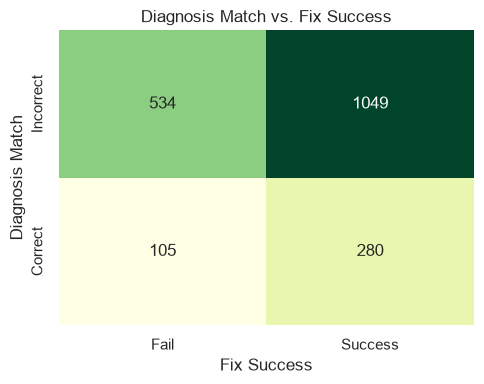

In [9]:
ct = pd.crosstab(df["diagnosis_match"], df["fix_success"])

plt.figure(figsize=(5, 4))

sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="YlGn",
    cbar=False,
    xticklabels=["Fail", "Success"],
    yticklabels=["Incorrect", "Correct"],
)

plt.title("Diagnosis Match vs. Fix Success")
plt.xlabel("Fix Success")
plt.ylabel("Diagnosis Match")
plt.tight_layout()
plt.show()

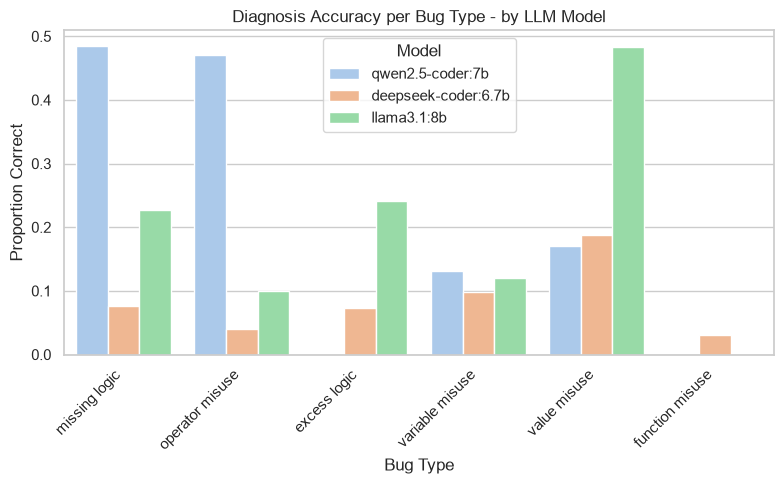

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="true_bug_type",
    y="diagnosis_match",
    hue="model_name",
    palette="pastel",
    errorbar=None,
    dodge=True
)
plt.title("Diagnosis Accuracy per Bug Type - by LLM Model")
plt.ylabel("Proportion Correct")
plt.xlabel("Bug Type")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

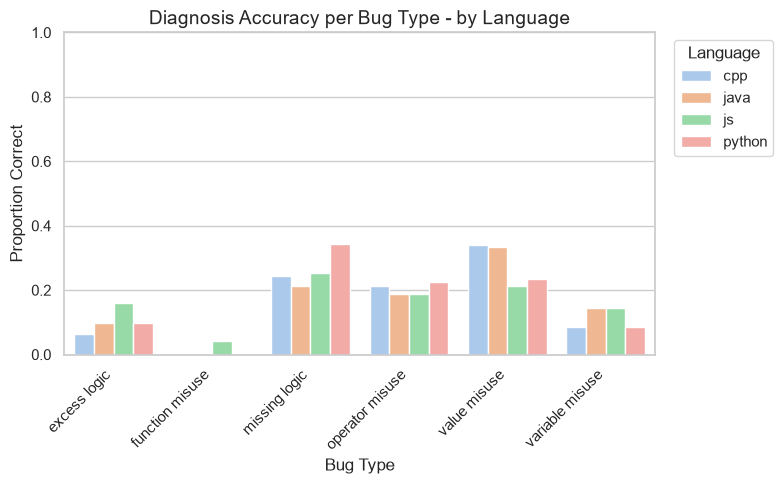

In [11]:
acc_by_lang = df.groupby(["language", "true_bug_type"])["diagnosis_match"].mean().unstack()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=acc_by_lang.reset_index().melt(id_vars="language",
                                        var_name="bug_type",
                                        value_name="accuracy"),
    x="bug_type",
    y="accuracy",
    hue="language",
    palette="pastel"
)

plt.title("Diagnosis Accuracy per Bug Type - by Language", fontsize=14)
plt.ylabel("Proportion Correct", fontsize=12)
plt.xlabel("Bug Type", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

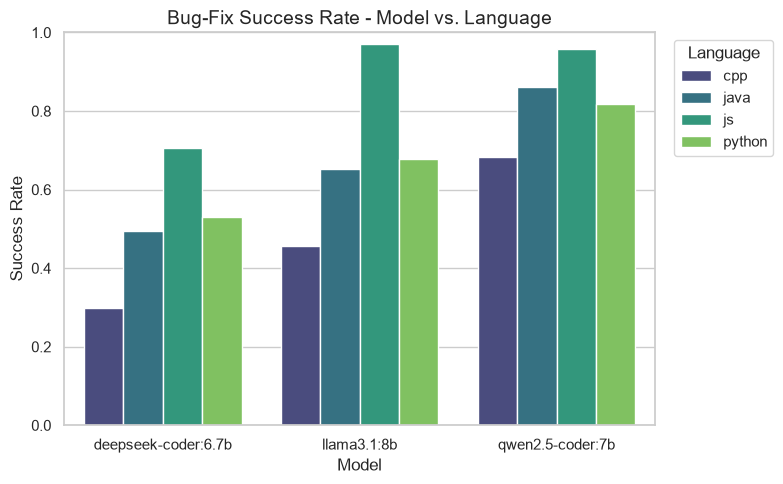

In [12]:
success_by_model_lang = df.groupby(["model_name", "language"])["fix_success"].mean().reset_index().rename(columns={"fix_success": "success_rate"})
success_by_model_lang["success_rate"] = success_by_model_lang["success_rate"].round(3)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=success_by_model_lang,
    x="model_name",
    y="success_rate",
    hue="language",
    palette="viridis",
    dodge=True
)

plt.title("Bug-Fix Success Rate - Model vs. Language", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Success Rate")
plt.ylim(0, 1)
plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
print("=== Diagnosis Accuracy (Top 5 groups) ===")
diag_rows = [{"breakdown": "overall", "group": "ALL", "diagnosis_accuracy": df["diagnosis_match"].mean()}]
for breakdown_col in ["language", "model_name", "true_bug_type"]:
    if breakdown_col in df.columns:
        for group_value, accuracy in df.groupby(breakdown_col)["diagnosis_match"].mean().items():
            diag_rows.append({"breakdown": breakdown_col, "group": group_value, "diagnosis_accuracy": accuracy})
display(pd.DataFrame(diag_rows).head())

print("\n=== Fix Success Rate (Top 5 groups) ===")
fix_rows = [{"breakdown": "overall", "group": "ALL", "fix_success_rate": df["fix_success"].mean()}]
for breakdown_col in ["language", "model_name", "true_bug_type"]:
    if breakdown_col in df.columns:
        for group_value, rate in df.groupby(breakdown_col)["fix_success"].mean().items():
            fix_rows.append({"breakdown": breakdown_col, "group": group_value, "fix_success_rate": rate})
display(pd.DataFrame(fix_rows).head())

print("\n=== Chi-Square Tests (Statistical Significance) ===")
chi2_results = []

def run_test(label, col_a, col_b):
    if col_a in df.columns and col_b in df.columns:
        contingency = pd.crosstab(df[col_a], df[col_b])
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            chi2, p_value, _, _ = chi2_contingency(contingency)
            chi2_results.append({"test": label, "p_value": p_value, "significant_at_0.05": p_value < 0.05})

run_test("diagnosis_match vs fix_success", "diagnosis_match", "fix_success")
run_test("true_bug_type vs fix_success", "true_bug_type", "fix_success")
run_test("model_name vs diagnosis_match", "model_name", "diagnosis_match")
run_test("language vs fix_success", "language", "fix_success")
display(pd.DataFrame(chi2_results))

=== Diagnosis Accuracy (Top 5 groups) ===


,breakdown,group,diagnosis_accuracy
0,overall,ALL,0.195630
1,language,cpp,0.197154
2,language,java,0.199187
3,language,js,0.189024
4,language,python,0.197154



=== Fix Success Rate (Top 5 groups) ===


,breakdown,group,fix_success_rate
0,overall,ALL,0.675305
1,language,cpp,0.479675
2,language,java,0.668699
3,language,js,0.878049
4,language,python,0.674797



=== Chi-Square Tests (Statistical Significance) ===


,test,p_value,significant_at_0.05
0,diagnosis_match vs fix_success,1.791710e-02,True
1,true_bug_type vs fix_success,2.195346e-03,True
2,model_name vs diagnosis_match,3.649497e-13,True
3,language vs fix_success,2.153214e-38,True


## Feature Engineering

In [14]:
y = df['fix_success']

# One-hot encode categorical features
categorical_features = ['language', 'model_name', 'true_bug_type', 'true_failure_symptom', 'predicted_bug_type']
existing_cat = [c for c in categorical_features if c in df.columns]

numerical_features = ['code_length', 'diagnosis_match']
existing_num = [c for c in numerical_features if c in df.columns]

X_cat = pd.get_dummies(df[existing_cat], drop_first=True)
X_num = df[existing_num].copy()

# Scale numerical features
if 'code_length' in X_num.columns:
    scaler = MinMaxScaler()
    X_num['code_length'] = scaler.fit_transform(X_num[['code_length']])
    
X = pd.concat([X_num, X_cat], axis=1)

In [15]:
# 80% Train - 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Features shape: {X.shape} | Target shape: {y.shape}")
print(f"Training set: {X_train.shape[0]} | Testing set: {X_test.shape[0]}")

Features shape: (1968, 20) | Target shape: (1968,)
Training set: 1574 | Testing set: 394


## Machine Learning Pipeline

In [16]:
MODEL_SPECS = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
}
PARAM_GRIDS = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
    "Decision Tree": {"max_depth": [3, 5, 8, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 5], "min_samples_leaf": [1, 2]},
    "Gradient Boosting": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1, 0.2], "max_depth": [2, 3, 4]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"], "gamma": ["scale", "auto"]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
}
tuned_results = []
best_models = {}

In [17]:
print("Training and Tuning 6 Models via GridSearchCV (Optimizing for Precision)\n")

for model_name, estimator in MODEL_SPECS.items():
    grid = GridSearchCV(
        estimator=clone(estimator),
        param_grid=PARAM_GRIDS[model_name],
        scoring="precision",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_models[model_name] = best_model
    
    preds = best_model.predict(X_test)
    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "Best Params": str(grid.best_params_)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("Precision", ascending=False)
display(tuned_df.drop(columns=["Best Params"]))

Training and Tuning 6 Models via GridSearchCV (Optimizing for Precision)



,Model,Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.743655,0.785467,0.853383,0.818018
1,Decision Tree,0.695431,0.782946,0.759398,0.770992
2,Random Forest,0.733503,0.771044,0.860902,0.813499
4,SVM,0.690355,0.762774,0.785714,0.774074
0,Logistic Regression,0.715736,0.756667,0.853383,0.802120
5,KNN,0.675127,0.742958,0.793233,0.767273


## Model Comparison Visuals & Feature Importance

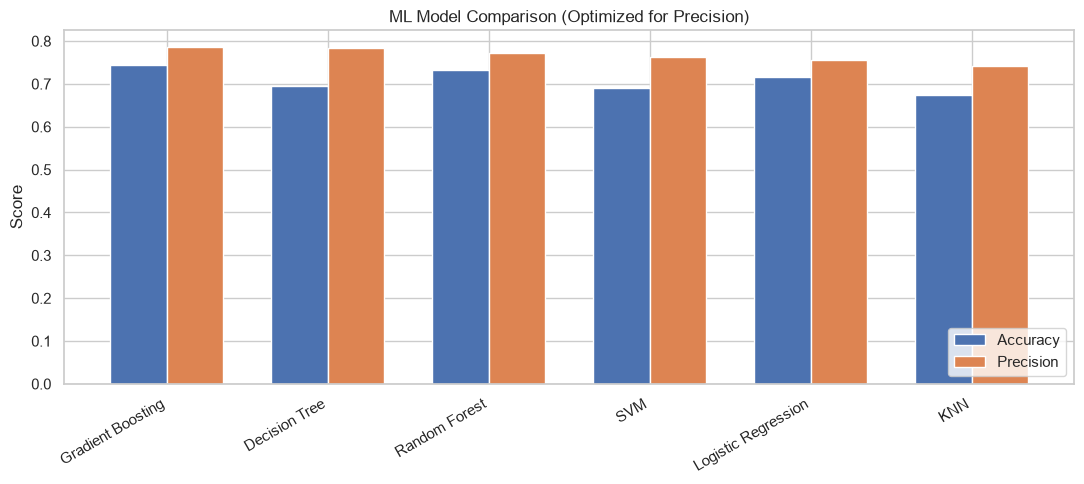

In [18]:
# 1. Model Score Comparison
plt.figure(figsize=(11, 5))
x = np.arange(len(tuned_df))
width = 0.35

plt.bar(x - width/2, tuned_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, tuned_df["Precision"], width, label="Precision") 

plt.xticks(x, tuned_df["Model"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("ML Model Comparison (Optimized for Precision)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()